# Saudi High-School Resource Allocation: Region-Paired Reproducible Analysis

This self-contained notebook reproduces **Tables 1-6 and Figures 1-4**. The public-versus-fee-paying inferential analysis first aggregates high-school records by **region and funding group**, then compares the paired regional ratios. Administrative cells are not treated as independent schools.

**Operational funding classification:** Government = publicly funded; Private + International = fee-paying. The source does not report tuition amounts, scholarships, or household expenditure.

## 1. Prepare the data file

Run the next cell. In Colab, upload either the Excel workbook or the complete project ZIP package when prompted.

In [1]:
from pathlib import Path as FilePath
import os
import shutil
import zipfile

EXPECTED_DATA_NAME = "Supplementary_Data_General_Education_Statistics_2024.xlsx"

try:
    import google.colab  # type: ignore
    WORKING_DIR = FilePath("/content")
except ImportError:
    WORKING_DIR = FilePath.cwd()

WORKING_DIR = FilePath(WORKING_DIR)
os.makedirs(str(WORKING_DIR), exist_ok=True)


def _find_data_file() -> FilePath | None:
    root = FilePath(WORKING_DIR)
    exact = list(root.rglob(EXPECTED_DATA_NAME))
    if exact:
        return FilePath(exact[0])
    candidates = [
        FilePath(p) for p in root.rglob("*.xlsx")
        if "general" in p.name.lower()
        and "education" in p.name.lower()
        and "stat" in p.name.lower()
    ]
    return candidates[0] if len(candidates) == 1 else None


def prepare_data_file() -> FilePath:
    found = _find_data_file()
    if found is None:
        try:
            from google.colab import files
        except ImportError as exc:
            raise FileNotFoundError(
                f"Place {EXPECTED_DATA_NAME} in {WORKING_DIR} and rerun this cell."
            ) from exc

        print("Upload the Excel workbook or the complete project ZIP package.")
        uploaded = files.upload()
        for uploaded_name in uploaded:
            uploaded_path = FilePath(WORKING_DIR) / str(uploaded_name)
            if uploaded_path.suffix.lower() == ".zip":
                extract_dir = FilePath(WORKING_DIR) / f"extracted_{uploaded_path.stem}"
                os.makedirs(str(extract_dir), exist_ok=True)
                with zipfile.ZipFile(str(uploaded_path), "r") as archive:
                    archive.extractall(str(extract_dir))
        found = _find_data_file()

    if found is None:
        raise FileNotFoundError(
            f"Could not locate {EXPECTED_DATA_NAME}. Upload the workbook and rerun."
        )

    standardized = FilePath(WORKING_DIR) / EXPECTED_DATA_NAME
    if FilePath(found).resolve() != standardized.resolve():
        shutil.copy2(str(found), str(standardized))
    print(f"Using data file: {standardized}")
    return standardized


DATA_PATH_READY = prepare_data_file()


Using data file: /mnt/data/school_revision_v3_regional_paired/Supplementary_Data_General_Education_Statistics_2024.xlsx


## 2. Analysis functions

In [2]:
"""Reproducible analysis for the Saudi high-school resource-allocation manuscript.

Place this script beside
`Supplementary_Data_General_Education_Statistics_2024.xlsx` and run:

    python Supplementary_Code_High_School_Analysis_v3.py

The script creates report-ready CSV tables and four figures in `analysis_outputs/`.
All descriptive and inferential comparisons are aligned to the 13 Saudi
administrative regions. The public-versus-fee-paying inferential analysis first
aggregates the 192 high-school administrative cells by region and funding group,
then compares the paired regional ratios. It does not treat administrative cells
as independent school-level observations.
"""

from __future__ import annotations

from pathlib import Path as FilePath
import math
import os
import warnings

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


BASE_DIR = FilePath.cwd()
DATA_PATH = FilePath(DATA_PATH_READY)
OUTPUT_DIR = FilePath(BASE_DIR / "analysis_outputs")
os.makedirs(str(OUTPUT_DIR), exist_ok=True)

EXPECTED_COLUMNS = {
    "Administrators",
    "Teachers",
    "Students",
    "Number of Schools",
    "Gender",
    "Education Type",
    "Stage",
    "Education Administration",
    "Region",
}

REGION_ORDER = [
    "Riyadh",
    "Makkah",
    "Eastern",
    "Asir",
    "Al Madinah",
    "Jazan",
    "Al-Qassim",
    "Tabuk",
    "Ha'il",
    "Al Jouf",
    "Najran",
    "Northern Borders",
    "Al Bahah",
]

SECTOR_ORDER = ["Government", "Private", "International"]
FUNDING_ORDER = [
    "Publicly funded (Government)",
    "Fee-paying (Private + International)",
]
COUNT_COLUMNS = ["Number of Schools", "Students", "Teachers", "Administrators"]
RATIO_COLUMNS = [
    "Students per School",
    "Students per Teacher",
    "Students per Administrator",
]


def clean_stale_outputs() -> None:
    """Remove obsolete cell-level inferential outputs from earlier versions."""
    stale = [
        "table6_welch_tests_high_school_cells.csv",
        "table6_paired_regional_comparison.csv",
        "supplementary_regional_funding_ratios.csv",
    ]
    for filename in stale:
        path = OUTPUT_DIR / filename
        if path.exists():
            path.unlink()


def safe_divide(numerator: pd.Series | float, denominator: pd.Series | float):
    """Divide while replacing zero denominators with NaN."""
    if isinstance(denominator, pd.Series):
        return numerator / denominator.replace(0, np.nan)
    if denominator == 0:
        return np.nan
    return numerator / denominator


def load_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Data file not found: {DATA_PATH}. Place the workbook beside this script."
        )

    source = pd.read_excel(DATA_PATH)
    missing = EXPECTED_COLUMNS.difference(source.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    for column in COUNT_COLUMNS:
        source[column] = pd.to_numeric(source[column], errors="raise")

    non_royal = source[source["Education Type"] != "Royal Commission"].copy()
    high_school = non_royal[non_royal["Stage"] == "High school"].copy()

    if high_school.empty:
        raise ValueError("No records were found with Stage == 'High school'.")

    high_school["Funding Group"] = np.where(
        high_school["Education Type"].eq("Government"),
        FUNDING_ORDER[0],
        FUNDING_ORDER[1],
    )
    return source, non_royal, high_school


def validate_totals(high_school: pd.DataFrame) -> None:
    totals = high_school[COUNT_COLUMNS].sum()
    expected = {
        "Number of Schools": 5356,
        "Students": 1451903,
        "Teachers": 120330,
        "Administrators": 14175,
    }
    for column, expected_value in expected.items():
        actual = int(totals[column])
        if actual != expected_value:
            warnings.warn(
                f"Unexpected total for {column}: {actual:,}; expected {expected_value:,}."
            )

    observed_regions = set(high_school["Region"].dropna().unique())
    missing_regions = set(REGION_ORDER).difference(observed_regions)
    if missing_regions:
        raise ValueError(f"Missing expected regions: {sorted(missing_regions)}")


def build_table1_regional_descriptives(high_school: pd.DataFrame) -> pd.DataFrame:
    regional = high_school.groupby("Region", as_index=True)[COUNT_COLUMNS].sum()
    regional = regional.reindex(REGION_ORDER)

    labels = {
        "Administrators": "Administrators",
        "Teachers": "Teachers",
        "Students": "Students",
        "Number of Schools": "No. of Schools",
    }
    rows: list[dict[str, object]] = []
    for column in ["Administrators", "Teachers", "Students", "Number of Schools"]:
        values = regional[column].dropna()
        rows.append(
            {
                "Metric": labels[column],
                "Total": int(values.sum()),
                "Mean": values.mean(),
                "Median": values.median(),
                "SD": values.std(ddof=1),
                "Minimum": int(values.min()),
                "Maximum": int(values.max()),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
            }
        )
    table = pd.DataFrame(rows)
    table.to_csv(OUTPUT_DIR / "table1_regional_descriptive_statistics.csv", index=False)
    return table


def add_derived_ratios(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["Students per School"] = safe_divide(
        result["Students"], result["Number of Schools"]
    )
    result["Students per Teacher"] = safe_divide(
        result["Students"], result["Teachers"]
    )
    result["Students per Administrator"] = safe_divide(
        result["Students"], result["Administrators"]
    )
    return result


def build_table2_sector_summary(high_school: pd.DataFrame) -> pd.DataFrame:
    sector = high_school.groupby("Education Type")[COUNT_COLUMNS].sum()
    sector = sector.reindex(SECTOR_ORDER)
    sector = add_derived_ratios(sector)
    sector.to_csv(OUTPUT_DIR / "table2_school_type_summary.csv")
    return sector


def build_table3_funding_summary(high_school: pd.DataFrame) -> pd.DataFrame:
    funding = (
        high_school.groupby("Funding Group")[COUNT_COLUMNS]
        .sum()
        .reindex(FUNDING_ORDER)
    )
    funding = add_derived_ratios(funding)

    totals = high_school[COUNT_COLUMNS].sum()
    funding["School share (%)"] = (
        funding["Number of Schools"] / totals["Number of Schools"] * 100
    )
    funding["Student share (%)"] = funding["Students"] / totals["Students"] * 100
    funding["Teacher share (%)"] = funding["Teachers"] / totals["Teachers"] * 100
    funding["Administrator share (%)"] = (
        funding["Administrators"] / totals["Administrators"] * 100
    )

    gender = (
        high_school.groupby(["Funding Group", "Gender"])["Students"]
        .sum()
        .unstack(fill_value=0)
        .reindex(FUNDING_ORDER)
    )
    for gender_name in ["Boys", "Girls"]:
        if gender_name not in gender.columns:
            gender[gender_name] = 0
    funding["Boys"] = gender["Boys"]
    funding["Girls"] = gender["Girls"]
    funding["Boys within group (%)"] = funding["Boys"] / funding["Students"] * 100
    funding["Girls within group (%)"] = funding["Girls"] / funding["Students"] * 100

    funding = funding[
        [
            "Number of Schools",
            "School share (%)",
            "Students",
            "Student share (%)",
            "Boys",
            "Boys within group (%)",
            "Girls",
            "Girls within group (%)",
            "Teachers",
            "Teacher share (%)",
            "Administrators",
            "Administrator share (%)",
            "Students per School",
            "Students per Teacher",
            "Students per Administrator",
        ]
    ]
    funding.to_csv(OUTPUT_DIR / "table3_public_vs_fee_paying_summary.csv")
    return funding


def build_table4_school_load(high_school: pd.DataFrame) -> pd.DataFrame:
    regional = high_school.groupby("Region")[COUNT_COLUMNS].sum()
    regional = add_derived_ratios(regional)
    national_mean = high_school["Students"].sum() / high_school["Number of Schools"].sum()
    table = regional[["Students per School"]].sort_values(
        "Students per School", ascending=False
    )
    table["Rank"] = table["Students per School"].rank(
        method="min", ascending=False
    ).astype(int)
    table["Difference from National Mean"] = (
        table["Students per School"] - national_mean
    )
    table = table[["Rank", "Students per School", "Difference from National Mean"]]
    table.to_csv(OUTPUT_DIR / "table4_regional_school_load.csv")
    return table


def build_table5_regional_summary(high_school: pd.DataFrame) -> pd.DataFrame:
    regional = high_school.groupby("Region")[COUNT_COLUMNS].sum()
    regional = add_derived_ratios(regional)
    regional["Load Rank"] = regional["Students per School"].rank(
        method="min", ascending=False
    ).astype(int)
    regional = regional.reindex(REGION_ORDER)
    regional.to_csv(OUTPUT_DIR / "table5_regional_summary.csv")
    return regional


def build_regional_funding_ratios(high_school: pd.DataFrame) -> pd.DataFrame:
    """Aggregate across gender and education administrations within region/funding group."""
    regional_funding = (
        high_school.groupby(["Region", "Funding Group"])[COUNT_COLUMNS]
        .sum()
        .reindex(
            pd.MultiIndex.from_product(
                [REGION_ORDER, FUNDING_ORDER], names=["Region", "Funding Group"]
            )
        )
    )
    if regional_funding["Students"].isna().any():
        missing = regional_funding[regional_funding["Students"].isna()].index.tolist()
        raise ValueError(f"Missing region/funding combinations: {missing}")

    regional_funding = add_derived_ratios(regional_funding).reset_index()
    regional_funding.to_csv(
        OUTPUT_DIR / "supplementary_regional_funding_ratios.csv", index=False
    )
    return regional_funding


def paired_effect_size_dz(differences: pd.Series) -> float:
    """Cohen's dz for paired observations."""
    return differences.mean() / differences.std(ddof=1)


def build_table6_paired_regional_comparison(
    high_school: pd.DataFrame,
) -> pd.DataFrame:
    regional_funding = build_regional_funding_ratios(high_school)
    wide = regional_funding.pivot(
        index="Region", columns="Funding Group", values=RATIO_COLUMNS
    ).reindex(REGION_ORDER)

    rows: list[dict[str, object]] = []
    for indicator in RATIO_COLUMNS:
        public = wide[(indicator, FUNDING_ORDER[0])]
        fee = wide[(indicator, FUNDING_ORDER[1])]
        paired = pd.concat([public, fee], axis=1).dropna()
        paired.columns = ["Publicly funded", "Fee-paying"]
        differences = paired["Publicly funded"] - paired["Fee-paying"]
        n = len(differences)

        paired_t = stats.ttest_rel(
            paired["Publicly funded"], paired["Fee-paying"], nan_policy="omit"
        )
        se = differences.std(ddof=1) / math.sqrt(n)
        critical_t = stats.t.ppf(0.975, df=n - 1)
        ci_low = differences.mean() - critical_t * se
        ci_high = differences.mean() + critical_t * se

        # Exact/automatic two-sided signed-rank sensitivity test.
        wilcoxon = stats.wilcoxon(
            paired["Publicly funded"],
            paired["Fee-paying"],
            alternative="two-sided",
            method="auto",
        )
        shapiro = stats.shapiro(differences)

        rows.append(
            {
                "Indicator": indicator,
                "Paired regions (n)": n,
                "Public mean": paired["Publicly funded"].mean(),
                "Public median": paired["Publicly funded"].median(),
                "Fee-paying mean": paired["Fee-paying"].mean(),
                "Fee-paying median": paired["Fee-paying"].median(),
                "Mean paired difference (Public - Fee-paying)": differences.mean(),
                "95% CI lower": ci_low,
                "95% CI upper": ci_high,
                "Paired t": paired_t.statistic,
                "Paired t p-value": paired_t.pvalue,
                "Wilcoxon W": wilcoxon.statistic,
                "Wilcoxon p-value": wilcoxon.pvalue,
                "Cohen dz": paired_effect_size_dz(differences),
                "Shapiro-Wilk p (paired differences)": shapiro.pvalue,
                "Regions Public > Fee-paying": int((differences > 0).sum()),
                "Regions Public < Fee-paying": int((differences < 0).sum()),
            }
        )

    table = pd.DataFrame(rows)
    table.to_csv(
        OUTPUT_DIR / "table6_paired_regional_comparison.csv", index=False
    )
    return table


def make_figure1(high_school: pd.DataFrame) -> None:
    regional = high_school.groupby("Region")[COUNT_COLUMNS].sum()
    sorted_regions = regional.sort_values("Students", ascending=False).index
    sorted_data = regional.loc[sorted_regions]

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    metrics = ["Students", "Teachers", "Administrators", "Number of Schools"]
    for metric, ax in zip(metrics, axes.flat):
        bars = ax.bar(sorted_data.index, sorted_data[metric])
        ax.set_title(metric)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:,.0f}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=8,
                xytext=(0, 3),
                textcoords="offset points",
            )
    fig.suptitle(
        "Regional Distribution of High-School Resources in Saudi Arabia",
        fontweight="bold",
    )
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / "figure1_regional_resources.png", dpi=300, bbox_inches="tight"
    )
    plt.close(fig)


def make_figure2(high_school: pd.DataFrame) -> None:
    gender = high_school.groupby(["Region", "Gender"])["Students"].sum().unstack(fill_value=0)
    for column in ["Boys", "Girls"]:
        if column not in gender.columns:
            gender[column] = 0
    gender["Total"] = gender["Boys"] + gender["Girls"]
    gender = gender.sort_values("Total", ascending=False)

    x = np.arange(len(gender))
    width = 0.38
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.bar(x - width / 2, gender["Boys"], width, label="Boys")
    ax.bar(x + width / 2, gender["Girls"], width, label="Girls")
    ax.set_xticks(x)
    ax.set_xticklabels(gender.index, rotation=45, ha="right")
    ax.set_ylabel("Students")
    ax.set_title("High-School Student Enrolment by Gender and Region")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / "figure2_gender_by_region.png", dpi=300, bbox_inches="tight"
    )
    plt.close(fig)


def make_figure3(high_school: pd.DataFrame) -> None:
    composition = high_school.pivot_table(
        index=["Region", "Gender"],
        columns="Education Type",
        values="Students",
        aggfunc="sum",
        fill_value=0,
    ).reindex(columns=SECTOR_ORDER, fill_value=0)
    percent = composition.div(composition.sum(axis=1), axis=0).fillna(0) * 100
    percent = percent.reset_index()
    percent["Region-Gender"] = percent["Region"] + " - " + percent["Gender"]
    percent = percent.set_index("Region-Gender")

    fig, ax = plt.subplots(figsize=(18, 8))
    bottom = np.zeros(len(percent))
    for sector in SECTOR_ORDER:
        values = percent[sector].to_numpy()
        ax.bar(percent.index, values, bottom=bottom, label=sector)
        bottom += values
    ax.set_ylim(0, 100)
    ax.set_ylabel("Share of students (%)")
    ax.set_title("High-School Student Distribution by School Type, Gender, and Region")
    ax.tick_params(axis="x", rotation=60)
    ax.legend(title="School type")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / "figure3_sector_gender_composition.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close(fig)


def make_figure4(high_school: pd.DataFrame) -> None:
    grouped = high_school.groupby(["Region", "Education Type"])[COUNT_COLUMNS].sum()
    grouped = add_derived_ratios(grouped).reset_index()
    long = grouped.melt(
        id_vars=["Region", "Education Type"],
        value_vars=RATIO_COLUMNS,
        var_name="Metric",
        value_name="Value",
    )

    g = sns.catplot(
        data=long,
        x="Region",
        y="Value",
        hue="Education Type",
        col="Metric",
        kind="bar",
        col_wrap=3,
        sharey=False,
        height=5.5,
        aspect=1.1,
        order=REGION_ORDER,
        hue_order=SECTOR_ORDER,
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("", "Ratio / average")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=55)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    g.fig.suptitle(
        "High-School Resource Ratios by Region and School Type",
        y=1.03,
        fontweight="bold",
    )
    g.fig.savefig(
        OUTPUT_DIR / "figure4_resource_ratios.png", dpi=300, bbox_inches="tight"
    )
    plt.close(g.fig)


def print_report(
    table1: pd.DataFrame,
    table2: pd.DataFrame,
    table3: pd.DataFrame,
    table4: pd.DataFrame,
    table5: pd.DataFrame,
    table6: pd.DataFrame,
) -> None:
    pd.set_option("display.max_columns", None)
    print("\nTABLE 1 — REGIONAL DESCRIPTIVE STATISTICS\n", table1.round(2).to_string(index=False))
    print("\nTABLE 2 — SCHOOL-TYPE SUMMARY\n", table2.round(2).to_string())
    print("\nTABLE 3 — PUBLICLY FUNDED VS FEE-PAYING\n", table3.round(2).to_string())
    print("\nTABLE 4 — REGIONAL SCHOOL LOAD\n", table4.round(2).to_string())
    print("\nTABLE 5 — REGIONAL SUMMARY\n", table5.round(2).to_string())
    print("\nTABLE 6 — PAIRED REGIONAL COMPARISON\n", table6.round(4).to_string(index=False))
    print(f"\nOutputs written to: {OUTPUT_DIR}")


def main() -> None:
    clean_stale_outputs()
    _, _, high_school = load_data()
    validate_totals(high_school)

    table1 = build_table1_regional_descriptives(high_school)
    table2 = build_table2_sector_summary(high_school)
    table3 = build_table3_funding_summary(high_school)
    table4 = build_table4_school_load(high_school)
    table5 = build_table5_regional_summary(high_school)
    table6 = build_table6_paired_regional_comparison(high_school)

    make_figure1(high_school)
    make_figure2(high_school)
    make_figure3(high_school)
    make_figure4(high_school)

    print_report(table1, table2, table3, table4, table5, table6)



## 3. Load and validate the high-school data

In [3]:
from IPython.display import display, Image

clean_stale_outputs()
source, non_royal, high_school = load_data()
validate_totals(high_school)
print(f"Source records: {len(source):,}")
print(f"Non-Royal Commission records: {len(non_royal):,}")
print(f"High-school administrative cells: {len(high_school):,}")
print(f"Regions: {high_school['Region'].nunique()}")
display(high_school.head())

Source records: 748
Non-Royal Commission records: 742
High-school administrative cells: 192
Regions: 13


,Administrators,Teachers,Students,Number of Schools,Gender,Education Type,Stage,Education Administration,Region,Funding Group
2,23,399,3026,19,Girls,Government,High school,Al-Makhwah,Al Bahah,Publicly funded (Government)
3,14,393,3147,17,Boys,Government,High school,Al-Makhwah,Al Bahah,Publicly funded (Government)
14,0,6,115,1,Boys,Private,High school,Al-Baha Region,Al Bahah,Fee-paying (Private + International)
15,40,788,6140,43,Girls,Government,High school,Al-Baha Region,Al Bahah,Publicly funded (Government)
16,26,761,5950,36,Boys,Government,High school,Al-Baha Region,Al Bahah,Publicly funded (Government)


## Table 1 - Descriptive Statistics Across the 13 Regional High-School Systems

In [4]:
table1 = build_table1_regional_descriptives(high_school)
display(table1.round(2))

,Metric,Total,Mean,Median,SD,Minimum,Maximum,Q1,Q3
0,Administrators,14175,1090.38,581.0,1238.85,71,4384,287.0,1468.0
1,Teachers,120330,9256.15,6018.0,9100.56,1655,29007,2717.0,10713.0
2,Students,1451903,111684.85,71184.0,115384.66,18409,358498,33383.0,114442.0
3,No. of Schools,5356,412.00,291.0,383.01,89,1310,133.0,517.0


## Table 2 - Comparative Resource Summary by School Type

In [5]:
table2 = build_table2_sector_summary(high_school)
display(table2.round(2))

,Number of Schools,Students,Teachers,Administrators,Students per School,Students per Teacher,Students per Administrator
Education Type,,,,,,,
Government,4003,1209480,104550,12684,302.14,11.57,95.35
Private,813,182580,11715,831,224.58,15.59,219.71
International,540,59843,4065,660,110.82,14.72,90.67


## Table 3 - Publicly Funded versus Fee-Paying High-School Provision

In [6]:
table3 = build_table3_funding_summary(high_school)
display(table3.round(2))

,Number of Schools,School share (%),Students,Student share (%),Boys,Boys within group (%),Girls,Girls within group (%),Teachers,Teacher share (%),Administrators,Administrator share (%),Students per School,Students per Teacher,Students per Administrator
Funding Group,,,,,,,,,,,,,,,
Publicly funded (Government),4003,74.74,1209480,83.3,582926,48.20,626554,51.80,104550,86.89,12684,89.48,302.14,11.57,95.35
Fee-paying (Private + International),1353,25.26,242423,16.7,157036,64.78,85387,35.22,15780,13.11,1491,10.52,179.17,15.36,162.59


The funding grouping is descriptive and does not estimate fees, affordability, expenditure, or cost-effectiveness.

## Tables 4 and 5 - Regional School Load and Regional Summary

In [7]:
table4 = build_table4_school_load(high_school)
table5 = build_table5_regional_summary(high_school)
display(table4.round(2))
display(table5.round(2))

,Rank,Students per School,Difference from National Mean
Region,,,
Eastern,1,321.92,50.84
Makkah,2,313.95,42.87
Jazan,3,275.59,4.51
Riyadh,4,273.66,2.58
Najran,5,268.29,-2.79
Tabuk,6,267.87,-3.21
Al Madinah,7,265.62,-5.46
Al Jouf,8,251.00,-20.08
Northern Borders,9,223.30,-47.78


,Number of Schools,Students,Teachers,Administrators,Students per School,Students per Teacher,Students per Administrator,Load Rank
Region,,,,,,,,
Riyadh,1310,358498,26423,4384,273.66,13.57,81.77,4
Makkah,1056,331535,29007,2468,313.95,11.43,134.33,2
Eastern,636,204741,15315,1974,321.92,13.37,103.72,1
Asir,517,114442,10713,1468,221.36,10.68,77.96,10
Al Madinah,383,101733,8876,1093,265.62,11.46,93.08,7
Jazan,291,80197,6018,535,275.59,13.33,149.90,3
Al-Qassim,330,71184,7339,640,215.71,9.70,111.22,11
Tabuk,180,48217,3549,581,267.87,13.59,82.99,6
Ha'il,194,37763,4009,181,194.65,9.42,208.64,12


## Table 6 - Paired Regional Comparison of Publicly Funded and Fee-Paying Ratios

In [8]:
table6 = build_table6_paired_regional_comparison(high_school)
display(table6.round(4))

,Indicator,Paired regions (n),Public mean,Public median,Fee-paying mean,Fee-paying median,Mean paired difference (Public - Fee-paying),95% CI lower,95% CI upper,Paired t,Paired t p-value,Wilcoxon W,Wilcoxon p-value,Cohen dz,Shapiro-Wilk p (paired differences),Regions Public > Fee-paying,Regions Public < Fee-paying
0,Students per School,13,272.4130,279.0303,163.1417,161.9466,109.2713,67.5294,151.0132,5.7037,0.0001,2.0,0.0007,1.5819,0.5423,12,1
1,Students per Teacher,13,11.3603,11.6098,16.0401,15.6495,-4.6798,-6.1472,-3.2124,-6.9485,0.0000,0.0,0.0002,-1.9272,0.2819,0,13
2,Students per Administrator,12,120.0914,98.7393,320.3634,340.6381,-200.2720,-282.3780,-118.1661,-5.3686,0.0002,1.0,0.0010,-1.5498,0.8684,1,11


Records are first summed within each **region x funding group** combination, collapsing across gender and education administrations. Ratios are calculated from those regional totals. Paired t-tests compare public and fee-paying values within the same region, and Wilcoxon signed-rank tests provide a non-parametric sensitivity analysis. The administrator comparison uses 12 regions because the fee-paying administrator total for Al Bahah is zero.

### Underlying paired regional values

In [9]:
regional_funding = build_regional_funding_ratios(high_school)
display(regional_funding.round(3))

,Region,Funding Group,Number of Schools,Students,Teachers,Administrators,Students per School,Students per Teacher,Students per Administrator
0,Riyadh,Publicly funded (Government),752,251414,20039,3759,334.327,12.546,66.883
1,Riyadh,Fee-paying (Private + International),558,107084,6384,625,191.907,16.774,171.334
2,Makkah,Publicly funded (Government),749,278378,24988,1971,371.666,11.140,141.237
3,Makkah,Fee-paying (Private + International),307,53157,4019,497,173.150,13.226,106.956
4,Eastern,Publicly funded (Government),430,171380,13054,1773,398.558,13.129,96.661
5,Eastern,Fee-paying (Private + International),206,33361,2261,201,161.947,14.755,165.975
6,Asir,Publicly funded (Government),471,107840,10255,1454,228.960,10.516,74.168
7,Asir,Fee-paying (Private + International),46,6602,458,14,143.522,14.415,471.571
8,Al Madinah,Publicly funded (Government),312,88947,7960,1035,285.087,11.174,85.939
9,Al Madinah,Fee-paying (Private + International),71,12786,916,58,180.085,13.959,220.448


## Figures 1-4

figure1_regional_resources.png


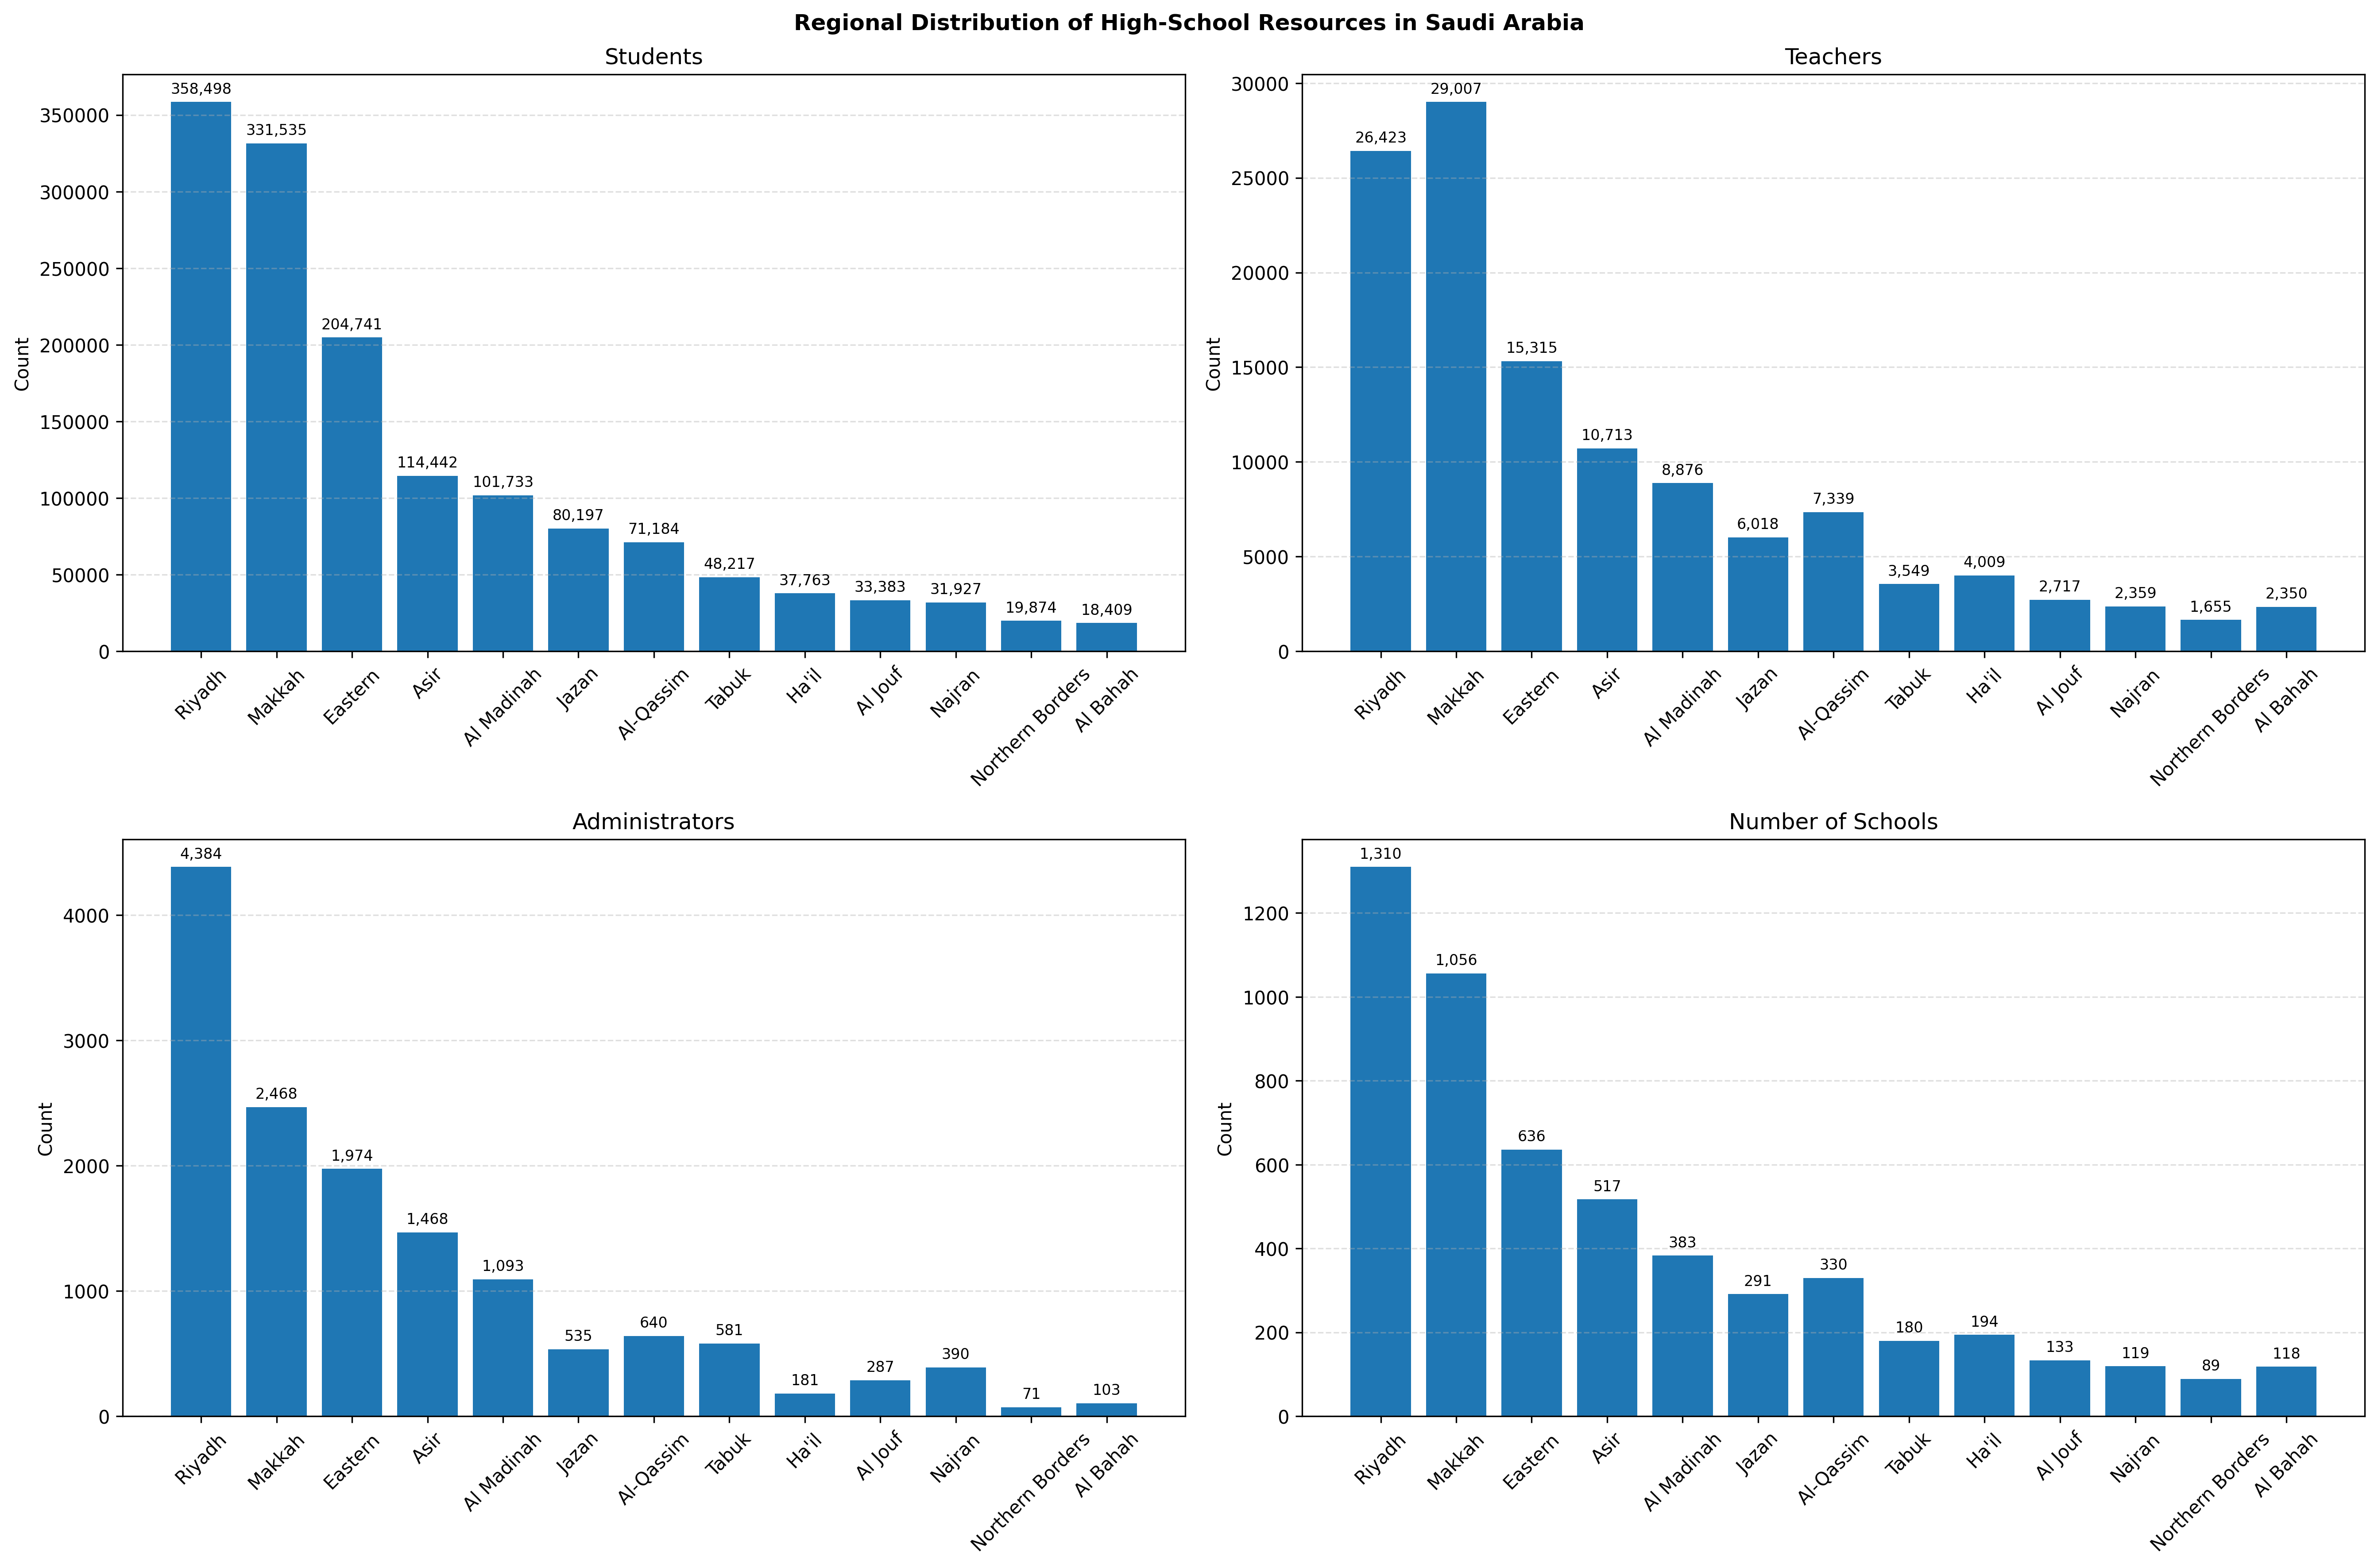

figure2_gender_by_region.png


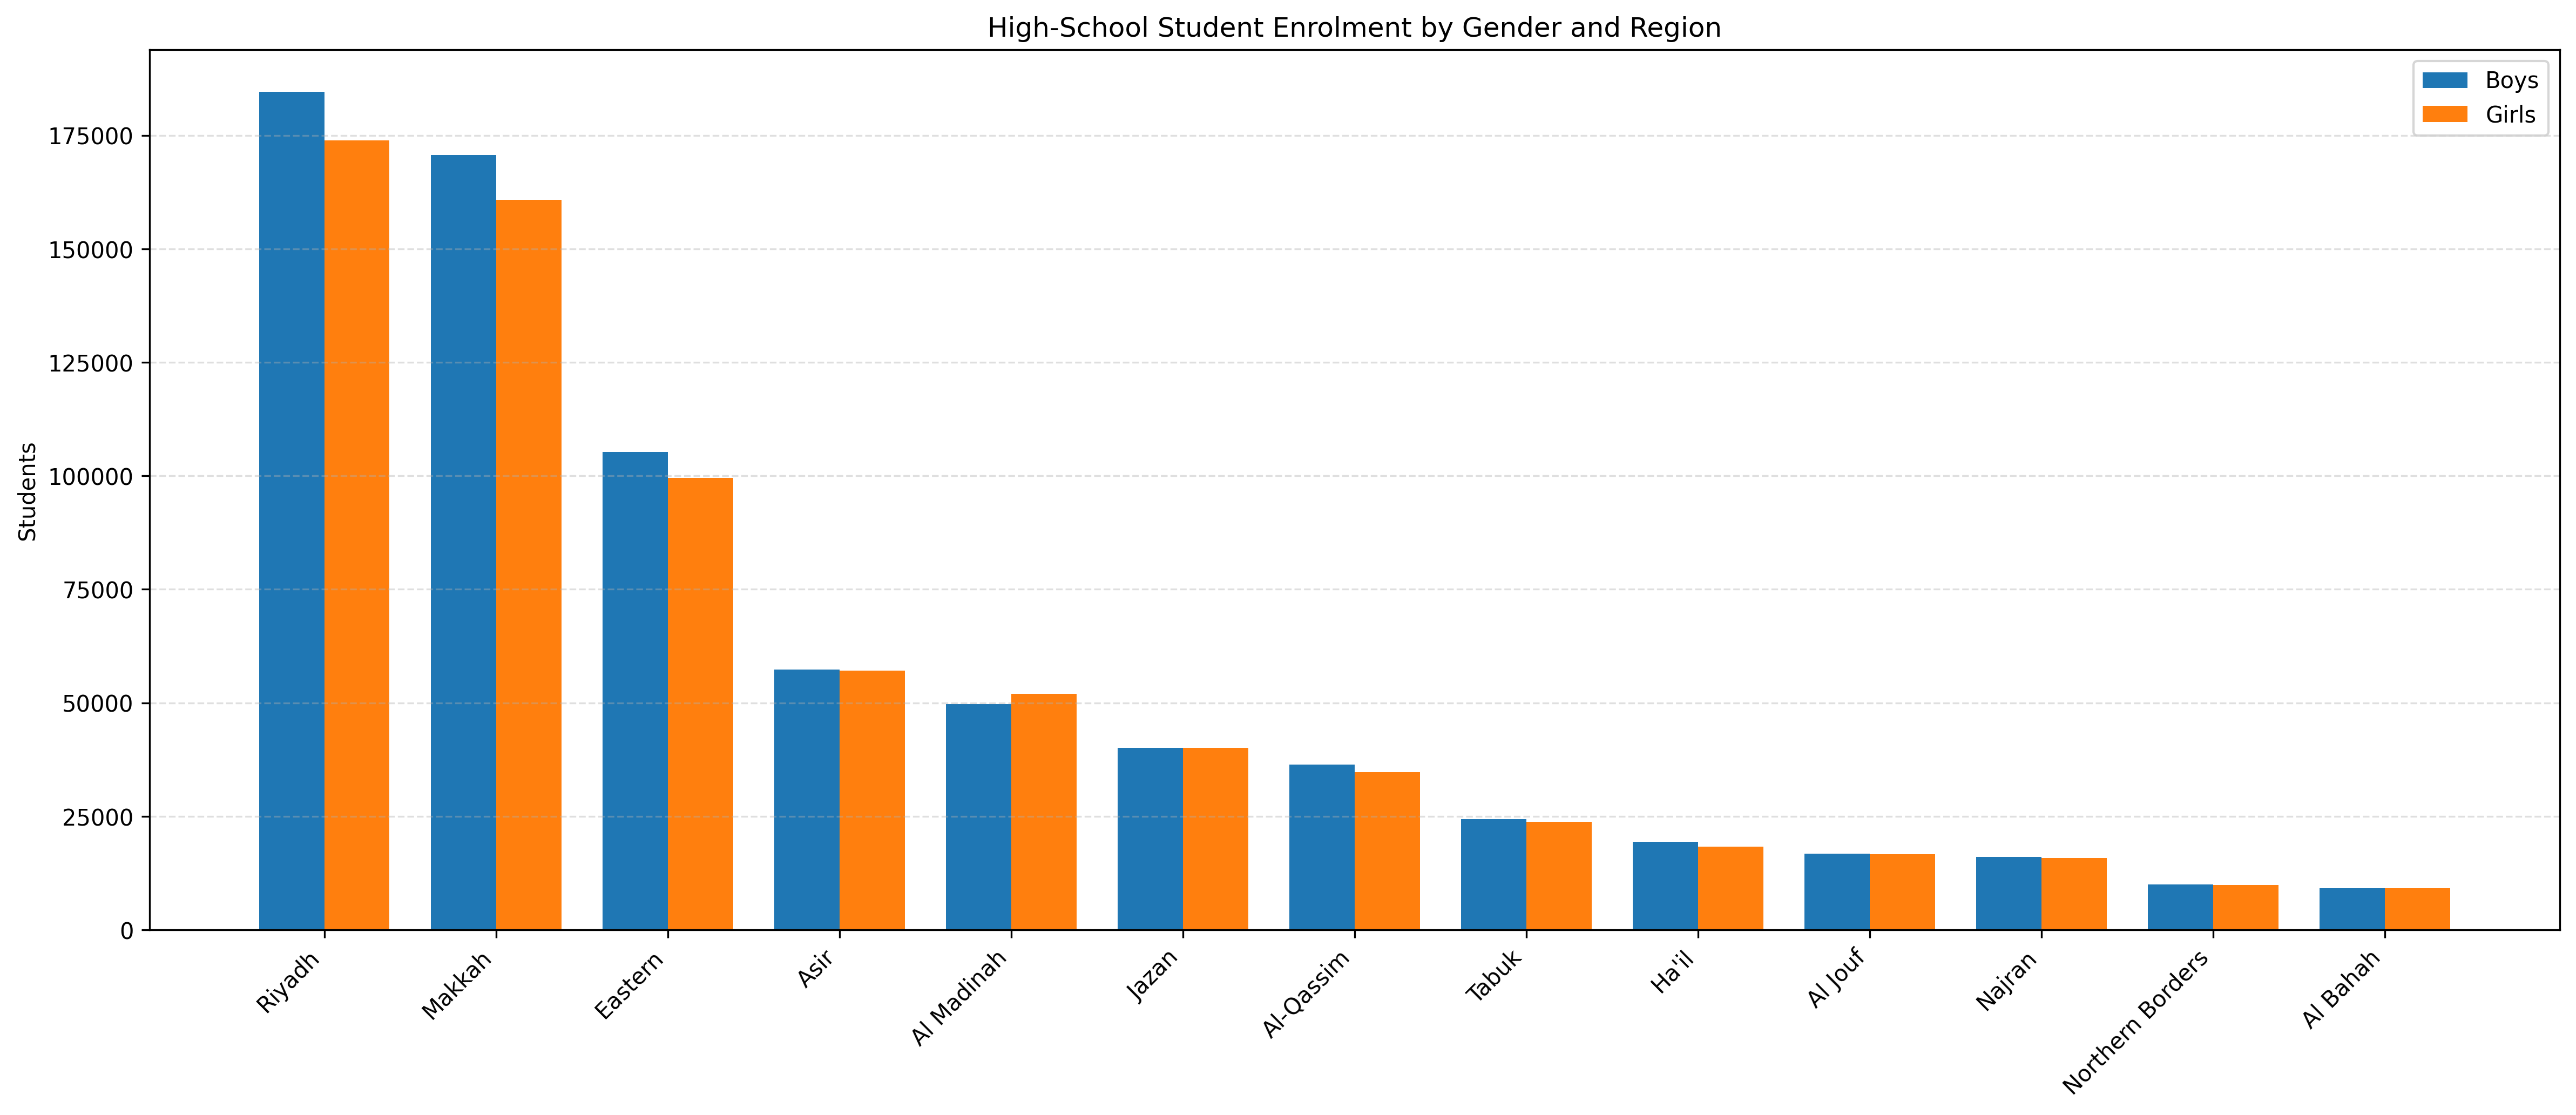

figure3_sector_gender_composition.png


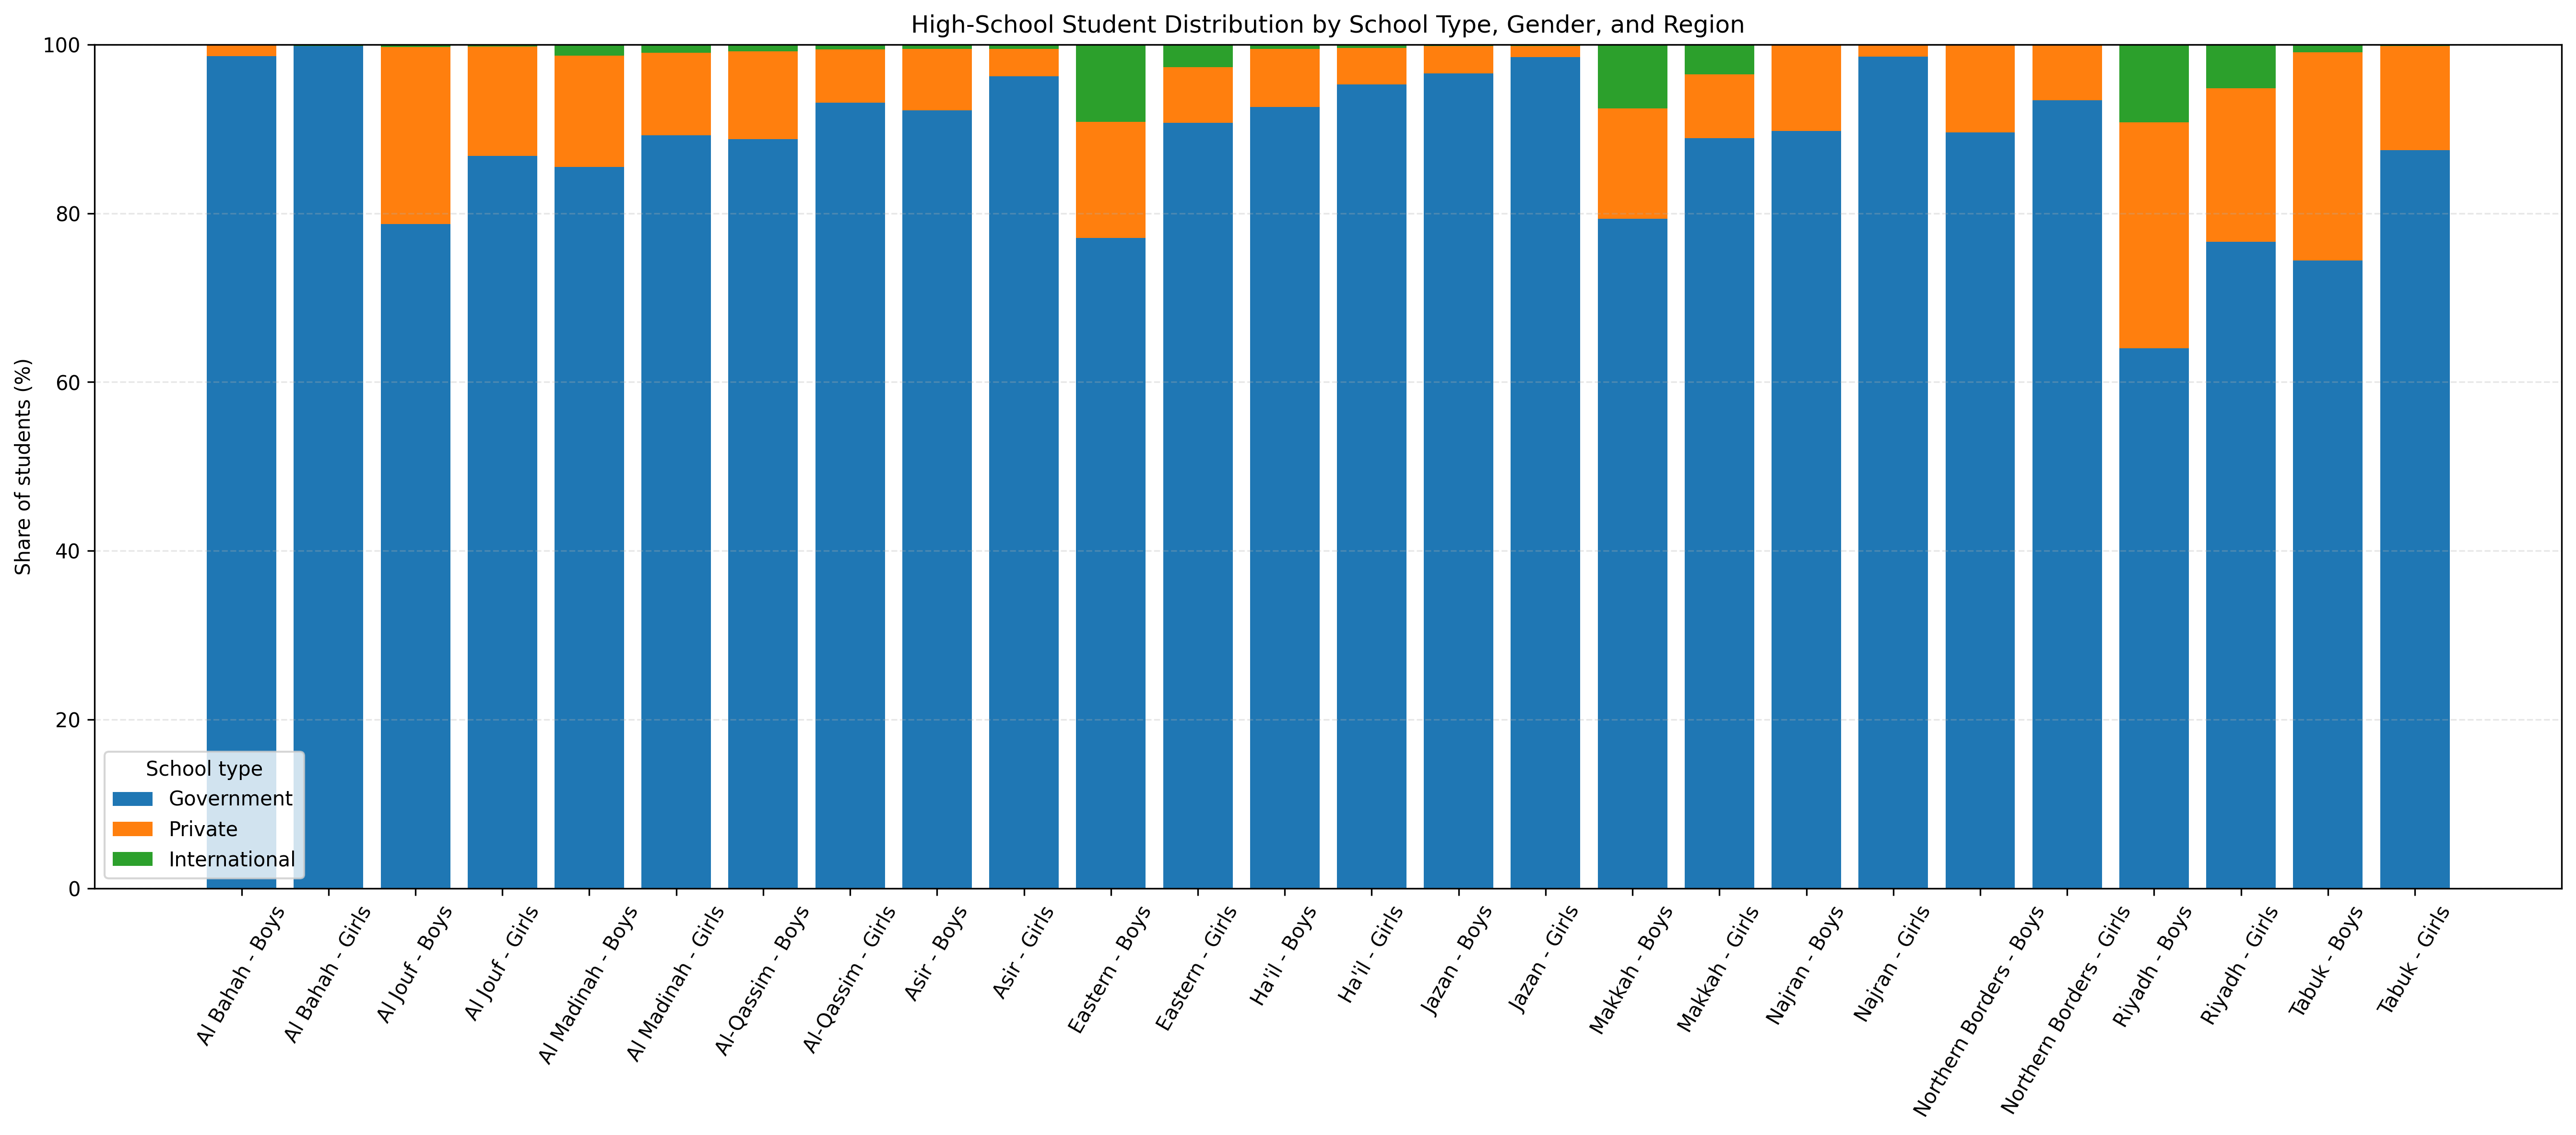

figure4_resource_ratios.png


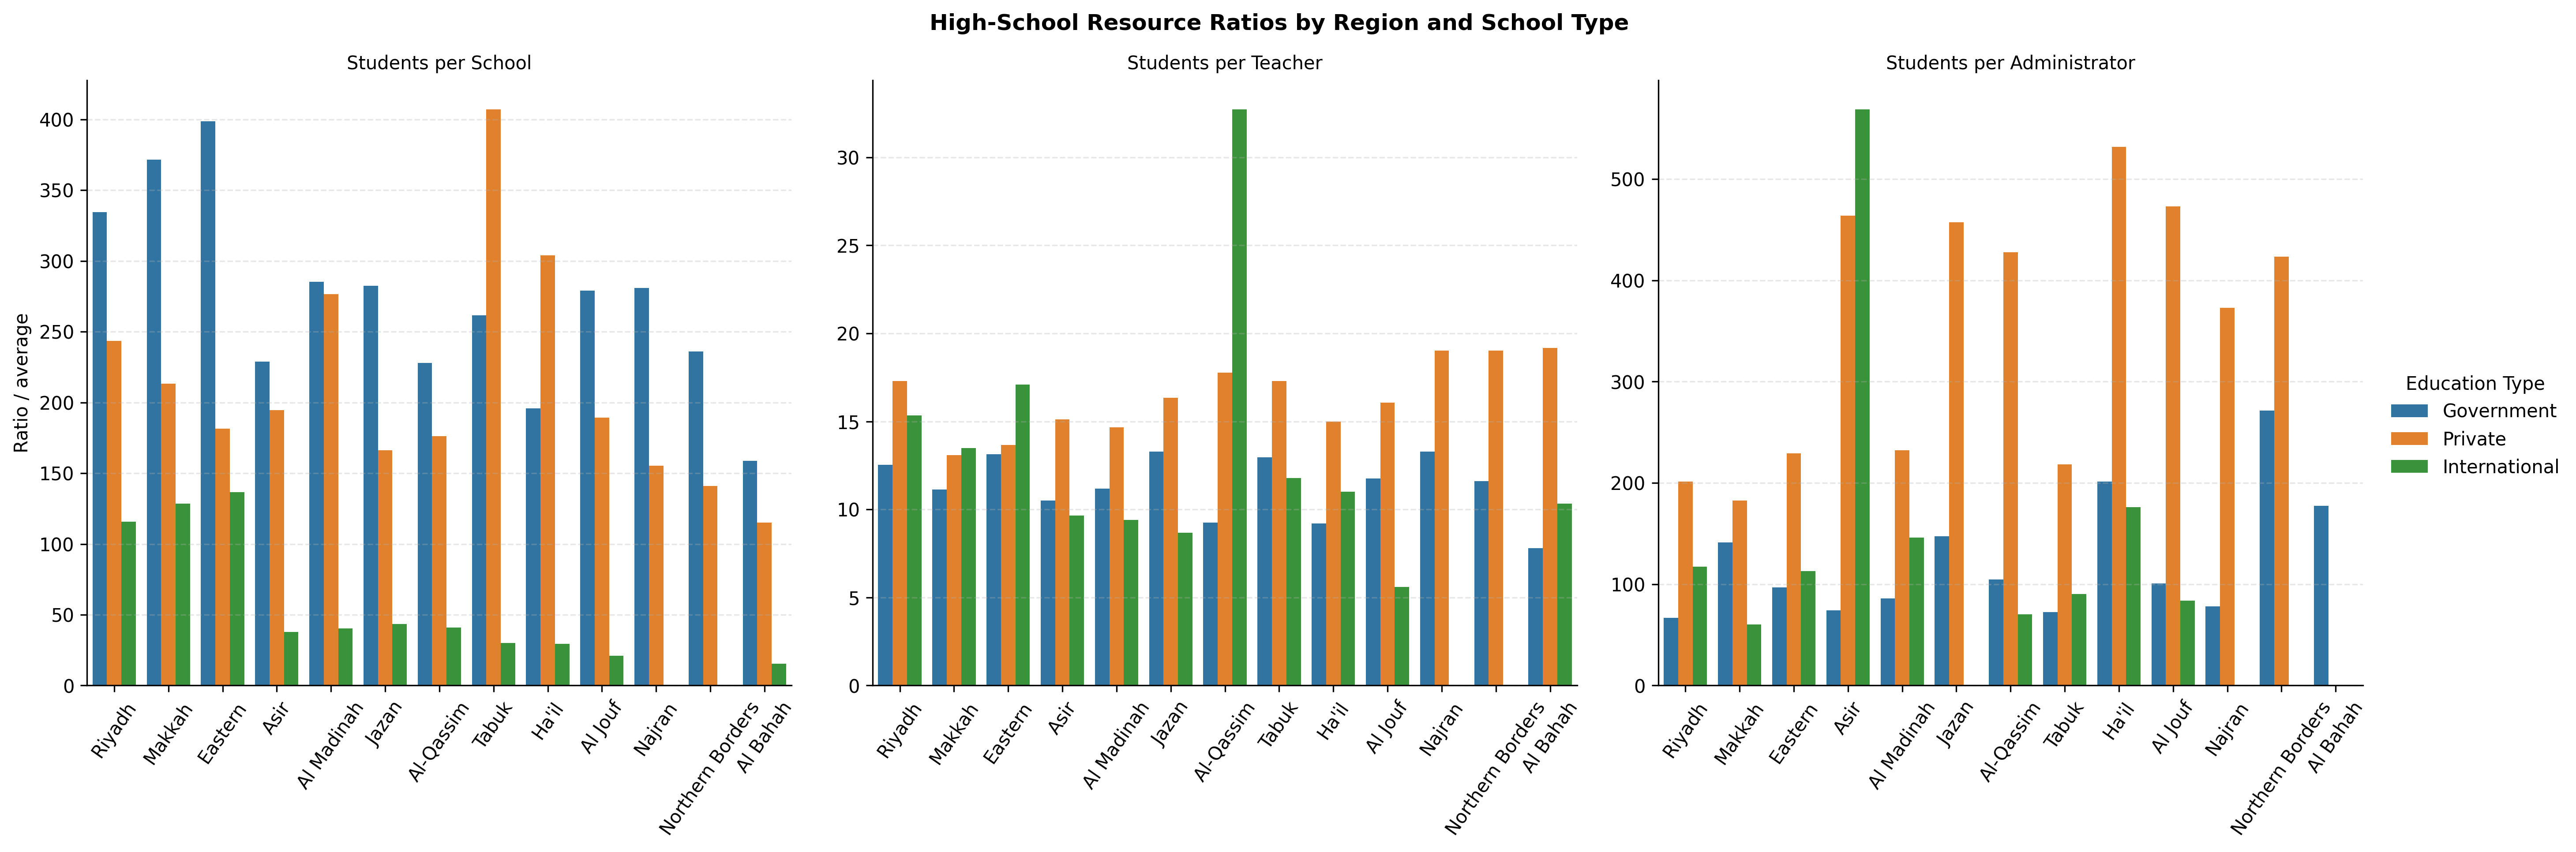

In [10]:
make_figure1(high_school)
make_figure2(high_school)
make_figure3(high_school)
make_figure4(high_school)

for filename in [
    "figure1_regional_resources.png",
    "figure2_gender_by_region.png",
    "figure3_sector_gender_composition.png",
    "figure4_resource_ratios.png",
]:
    print(filename)
    display(Image(filename=str(OUTPUT_DIR / filename), width=900))

## 4. Export all generated tables and figures

In [11]:
import shutil

archive_path = FilePath(shutil.make_archive(
    str(FilePath.cwd() / "High_School_Analysis_Outputs_v3"),
    "zip",
    root_dir=str(OUTPUT_DIR),
))
print(f"Output archive created: {archive_path}")

try:
    from google.colab import files
    print("To download immediately, run:")
    print(f"files.download('{archive_path.name}')")
except ImportError:
    pass

Output archive created: /mnt/data/school_revision_v3_regional_paired/High_School_Analysis_Outputs_v3.zip


### Optional Colab download

In [12]:
# from google.colab import files
# files.download('High_School_Analysis_Outputs_v3.zip')